# ETF轮动策略中动量因子的性能评估

## 获取数据，取股票池中所有ETF全部上市后的时间，尽量靠近上市时间

In [139]:
# 风险及免责提示：该策略由聚宽用户在聚宽社区分享，仅供学习交流使用。
# 原文一般包含策略说明，如有疑问请到原文和作者交流讨论。
# 原文网址：https://www.joinquant.com/view/community/detail/35693 
# 标题：轮动ETF策略中的动量因子分析
# 作者：量客攻城狮

## 这几只ETF中，消费ETF上市时间最晚，为2013-09-16

stkList = ['510050.XSHG',  '159928.XSHE',  '510300.XSHG',  '159915.XSHE']#, '515700.XSHG']
start, end = '2013-09-20', '2021-12-01'

data = []
for stk in stkList:
    data.append([stk,get_price(stk,start_date=start,end_date=end,fields=['close','open'],skip_paused=True)])
data[0][-1].shape

import pandas as pd

cdata = pd.DataFrame()
for item in data:
    cdata[item[0].split('.')[0]] = item[-1].close

## 查看每只ETF在历史上的单日收益率分布-符合事实与预期

a) 可以看出这几只ETF单日收益均值都大于0，但仅万分位上有效，说明这几只ETF长期是上涨的，但涨幅有限。

b) 四只ETF中，平均年化最高的是消费ETF，其次是创业板ETF，50ETF与沪深300ETF的收益则相近，大约为13%。数据符合事实与预期。

c) 这几只ETF单日收益率的直方图在0值附近对称分布，大体与高斯分布近似，说明涨跌概率大致都在50%，近乎随机，这与事实是吻合的。

d) 年化收益率计算：$r_y=(1+r_d)^{250}-1$，其中下表y和d分别表示年周期与日周期。

e) 根据波动率可以算出几只ETF的夏普比率$SR=\frac{R}{\sigma}$，可以看出它们自身的SR都小于1，单位波动带来的收益少。

510050    0.121476
159928    0.231354
510300    0.128812
159915    0.178814
Name: mean, dtype: float64
510050    0.514932
159928    0.837915
510300    0.531498
159915    0.519310
dtype: float64


,510050,159928,510300,159915
count,1994.000000,1994.000000,1994.000000,1994.000000
mean,0.000486,0.000925,0.000515,0.000715
std,0.014920,0.017463,0.015328,0.021777
min,-0.100043,-0.101695,-0.100114,-0.100180
25%,-0.005885,-0.007843,-0.005959,-0.009306
50%,0.000000,0.000000,0.000366,0.000345
75%,0.006834,0.009299,0.007292,0.011071
max,0.088681,0.101370,0.100000,0.100087


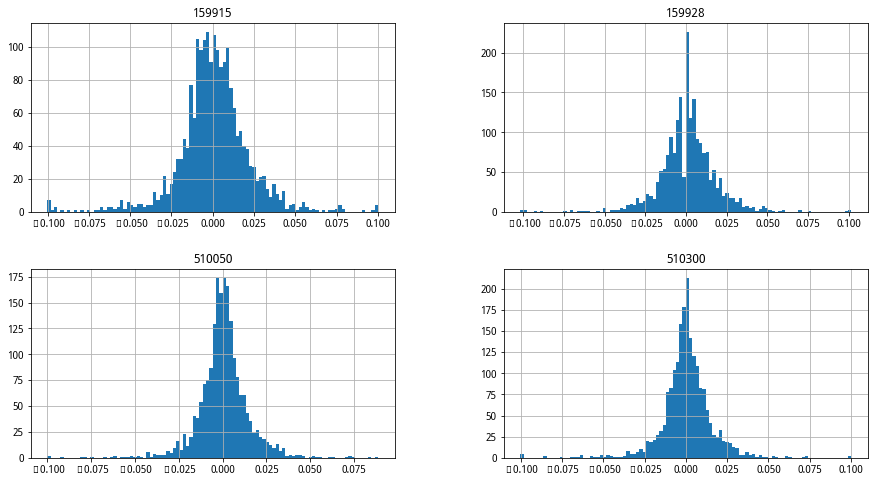

In [145]:
cdata.pct_change().hist(bins=100,figsize=(15,8))  # 单日收益率分布
x = cdata.pct_change().describe() # 单日收益率统计值
print(x.loc['mean',:]*250)  # 计算平均年化，用了近似公式
print(x.loc['mean',:]*250/(x.loc['std',:]*np.sqrt(250)))  # 计算平均年化，用了近似公式
cdata.pct_change().describe()

## 查看两只年化最高的ETF的累计收益率走势

这两只ETF的累计收益率涨幅较大，与其年化数据吻合，且可以看出它们的波动性更强。

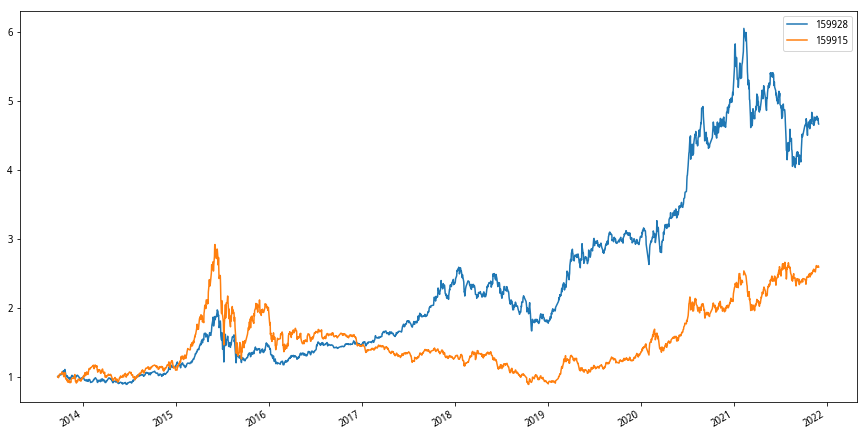

In [79]:
(cdata.iloc[:,[1,-1]]/cdata.iloc[0,[1,-1]]).plot(figsize=(15,8))


## 动量因子：近 M 日累计收益率的线性回归系数

长期看，动量因子都是正值，意味着股市长期上涨，与上面的结论吻合。

,slp_3,slp_5,slp_10,slp_20,slp_30,slp_60
count,7969.000000,7959.000000,7934.000000,7884.000000,7834.000000,7684.000000
mean,0.066026,0.066080,0.066447,0.067329,0.069490,0.071423
std,1.260215,0.892824,0.597134,0.424090,0.359462,0.274063
min,-9.501348,-7.057578,-3.831743,-2.549787,-1.854944,-0.782207
25%,-0.516351,-0.357640,-0.213340,-0.138254,-0.115796,-0.083474
50%,0.057230,0.072054,0.067194,0.063201,0.054667,0.045632
75%,0.671406,0.522504,0.373500,0.270386,0.229826,0.177318
max,10.542169,10.294892,4.168063,2.078336,1.706044,1.477531


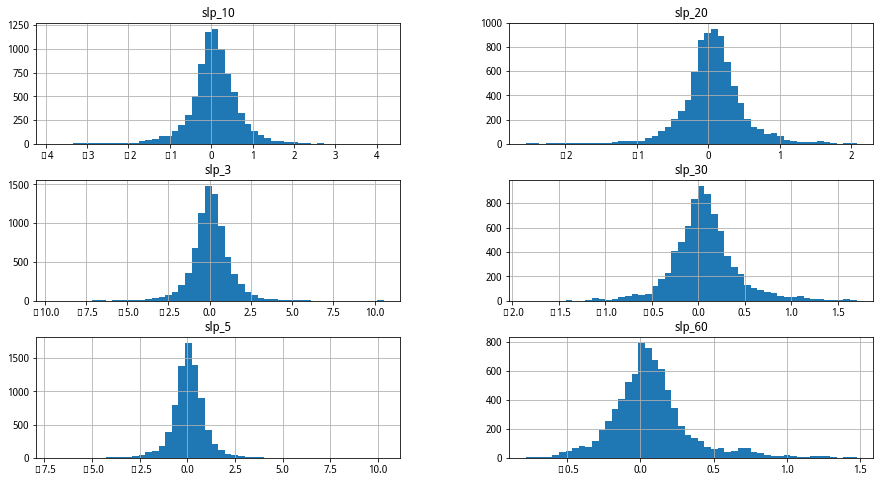

In [152]:
columns = ['slp_' + str(i) for i in [3,5,10,20,30,60]]
slps = pd.DataFrame(np.zeros((len(cdata)*4,6)),columns=columns)
slps.iloc[:,:] = np.nan # 分配内存

for i in [3,5,10,20,30,60]:
    slps.loc[:,'slp_'+str(i)] = cdata.rolling(i).apply(lambda x: 100*np.polyfit(np.arange(len(x)),x/x[0],1)[0],raw=True).values.reshape((-1,1))

slps.hist(figsize=(15,8),bins=50)
slps.describe()


## 获得每个ETF的N日累计收益

统计了向后1、5、10、20、30、60、90日收益，结论同上，市场长期上涨，周期越长，上涨幅度越大，上涨概率越高。

,ret_1,ret_5,ret_10,ret_20,ret_30,ret_60,ret_90
count,7974.000000,7958.000000,7938.000000,7898.000000,7858.000000,7738.000000,7618.000000
mean,1.000655,1.003330,1.006646,1.013347,1.020589,1.042086,1.064029
std,0.017577,0.038716,0.054528,0.078421,0.100521,0.149261,0.184137
min,0.898305,0.718415,0.593623,0.538571,0.548368,0.461783,0.572147
25%,0.992901,0.984617,0.981133,0.972775,0.966200,0.955465,0.945752
50%,1.000000,1.003446,1.007456,1.011100,1.014269,1.026979,1.043768
75%,1.008620,1.023410,1.033694,1.050492,1.065328,1.104400,1.142195
max,1.101370,1.267048,1.450237,1.464176,1.625539,2.004255,2.400253


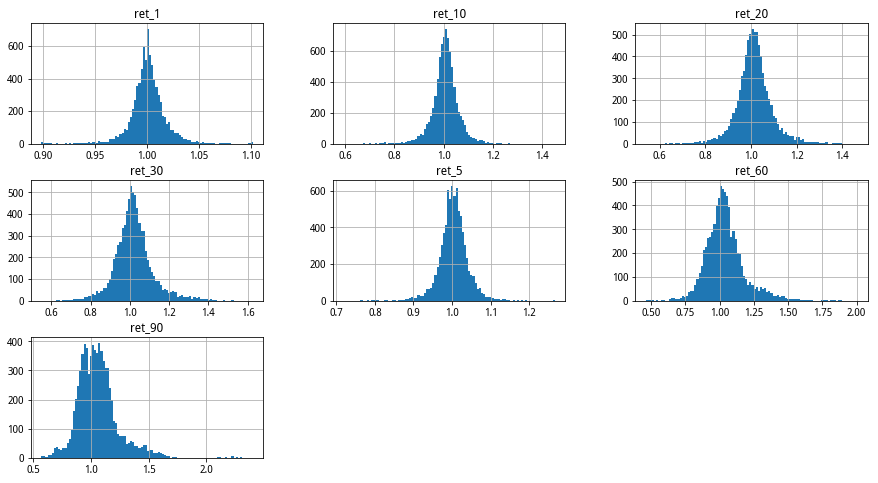

In [117]:
columns2 = ['ret_' + str(i) for i in [1,5,10,20,30,60,90]]
rets = pd.DataFrame(np.zeros((len(cdata)*4,7)),columns=columns2)
rets.iloc[:,:] = np.nan

for i in [1,5,10,20,30,60,90]:
    rets.loc[:,'ret_' + str(i)] = (cdata.shift(-i)/cdata).values.reshape(-1,1)
rets.hist(bins=100,figsize=(15,8))
rets.describe()

## 因子IC：所有ETF、所有日期共同统计

a) IC是指信息系数，指因子的预期收益率与真实收益率的相关系数。这里由于没有预期收益率，直接用因子值代替。真实收益率取了N日累计涨幅。

b) IC绝对值越高，则表示因子有效性越高。IC值绝对值越大越好，正值IC作为正向因子，负值IC表示因子可以反向预测，在可以做空的市场比较有用。

c) 这里考虑的是因子对未来走势的预测能力，意味着持仓周期是N天，在动态止损与择时中还需要重新考虑。

d) 这里考虑的是所有日期所有ETF的统计IC，反映的是宏观上IC的有效性。

e) 结论：针对这几只ETF，某几个周期的因子相对有效，且有效性在相似持仓周期上效果类同。10日因子对20日走势、20日因子对10日和20日走势正向预测较好；30日因子对60日走势、60日因子对30日和60日走势的反向预测较好。这两类应该可以组合起来，正向用20-10组合监测，同步用60-60组合预测反向。

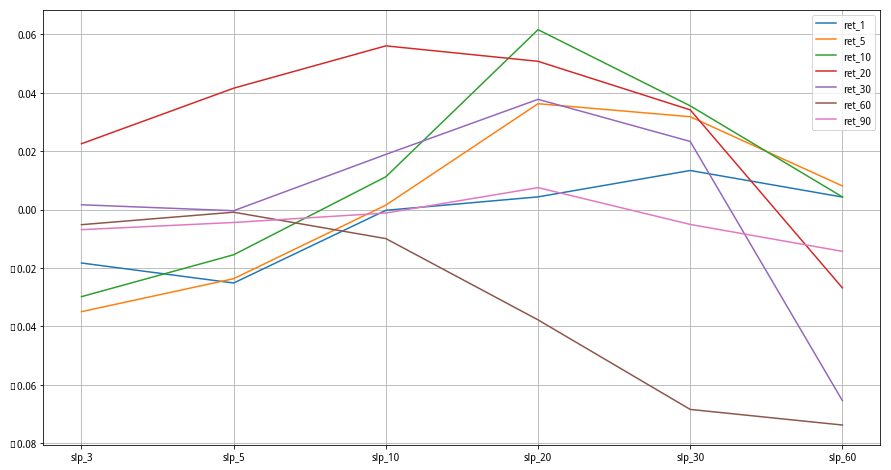

In [298]:
IC = pd.concat([slps,rets],axis=1).corr().iloc[:6,6:]
IC.plot(figsize=(15,8),xticks=range(6),grid=True)

## 因子IC：所有ETF的单日IC在时间周期上的分布

a) 有显著正向和反向预测作用的因子与前面结论基本一直；

b) 对于某个因子来讲，其对未来走势的预测能力偏向于向±1集中，及在时间维度上，这个因子预测未来走势不是涨就是跌，而且胜率比较高，这样因子有效性和持续性就得到了保证。

c) 在时间维度上，比较理想的因子IC分布是稳定值且这个值显著大于0或显著小于0，半衰期很长，这样对市场的冲击和成本控制比较有利。但现实条件下，很难找到这种因子，因为市场一直在变化。一般情况下，因子IC的分布可能是快速下降的陡坡或者U形，在这个动量策略中因子IC的分布就是U形。

In [176]:
slps_date = []
for i in [3,5,10,20,30,60]:
    slps_date.append(cdata.rolling(i).apply(lambda x: 100*np.polyfit(np.arange(len(x)),x/x[0],1)[0],raw=True))

rets_date = []
for i in [1,5,10,20,30,60,90]:
    rets_date.append(cdata.shift(-i)/cdata)


In [215]:
slps_date = pd.concat([slps_date[i] for i in range(len(slps_date))],axis=1)
rets_date = pd.concat([rets_date[i] for i in range(len(rets_date))],axis=1)


slp_col = ['slp_' + str(i) for i in [3,5,10,20,30,60]]
ret_col = ['ret_' + str(i) for i in [1,5,10,20,30,60,90]]
cors = []
for date in cdata.index[:100]:
    tmp_slp = pd.DataFrame(slps_date.loc[date,:].values.reshape((len(slp_col),4)),index=slp_col).T
    tmp_ret = pd.DataFrame(rets_date.loc[date,:].values.reshape((len(ret_col),4)),index=ret_col).T
    cor = pd.concat([tmp_slp,tmp_ret],axis=1).corr().iloc[:len(slp_col),len(slp_col):]
    cors.append(cor)

array([[AxesSubplot(0.125,0.670278;0.215278x0.209722),
        AxesSubplot(0.404861,0.670278;0.215278x0.209722),
        AxesSubplot(0.684722,0.670278;0.215278x0.209722)],
       [AxesSubplot(0.125,0.397639;0.215278x0.209722),
        AxesSubplot(0.404861,0.397639;0.215278x0.209722),
        AxesSubplot(0.684722,0.397639;0.215278x0.209722)],
       [AxesSubplot(0.125,0.125;0.215278x0.209722),
        AxesSubplot(0.404861,0.125;0.215278x0.209722),
        AxesSubplot(0.684722,0.125;0.215278x0.209722)]], dtype=object)

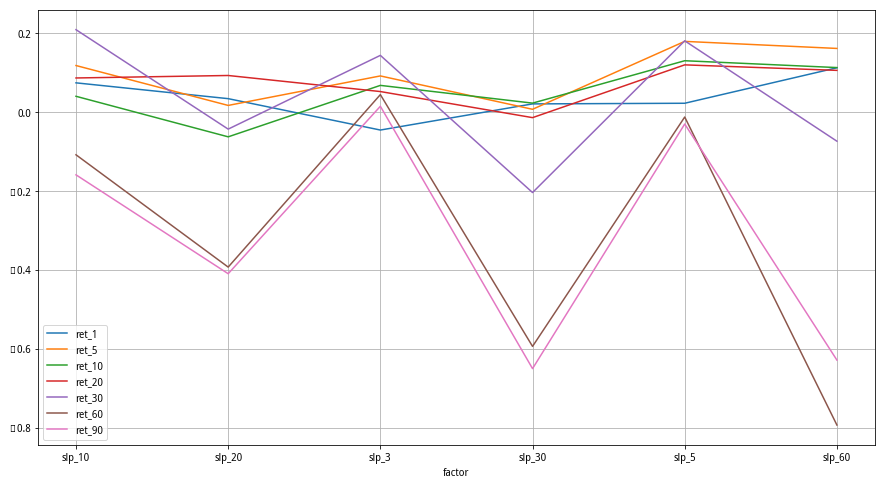

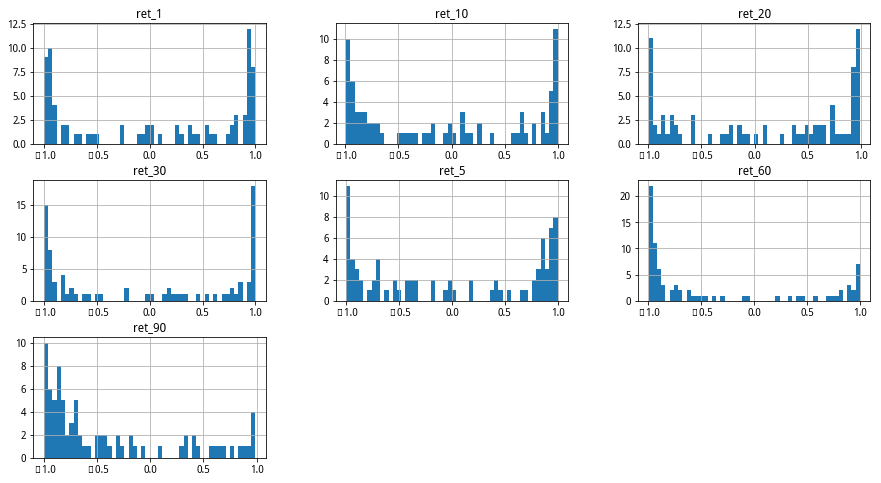

In [389]:

dates = list(cdata.index[:100])*len(slp_col)

dates.sort()
dates
# cors.loc[:,'date'] = dates
x = pd.concat(cors)
x['date'] = dates
x.index.name = 'factor'
t = x.reset_index().groupby(by='factor')
t.agg(np.mean).plot(figsize=(15,8),xticks=range(len(slp_col)),grid=True)
t.get_group('slp_20').iloc[:,1:-1].hist(figsize=(15,8),bins=50)

## 因子IC：每日选最强动量

这里只算了20天动量因子相对各个周期label之间的相关系数，20日动量排序后取最大的那个。

结果：10天持仓周期的return相关系数是最高的，与前面的分析吻合。

In [342]:
test = []
dates = cdata.index
for date in dates[:]:
    x = slps_date.loc[date].iloc[12:16].sort_values(ascending=False)
    code, slp = x.index[0], x.values[0]
    rts = rets_date.loc[date,:].loc[code]
    test.append([slp]+list(rts))

1995


In [351]:
pd.DataFrame(test).corr().iloc[:1,1:]

,1,2,3,4,5,6,7
0,0.022546,0.098599,0.146535,0.093742,0.018514,-0.031982,-0.010688


## 因子半衰期：约9-10天

对每只ETF，动量因子自相关系数的半衰期大概都是9-10天，可见因子的稳定性比较好。

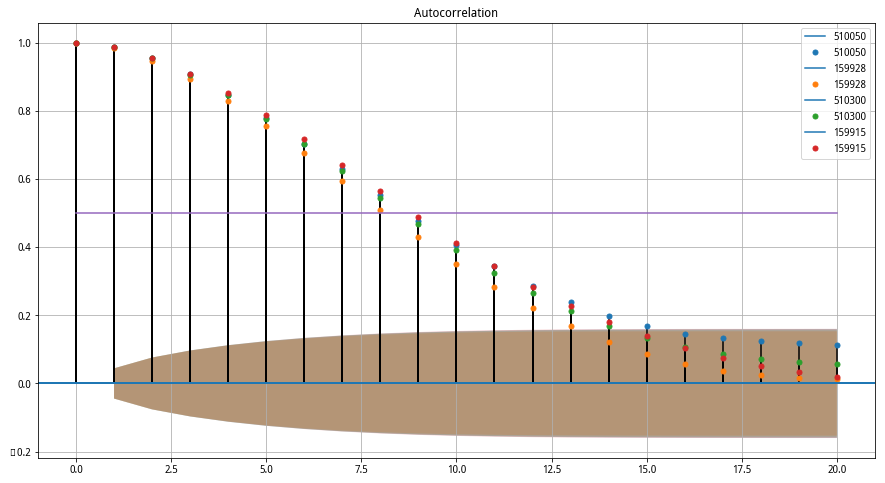

In [386]:
## 画出每只ETF的20天动量因子自相关系数
import statsmodels.api as sm
slp_20 = slps_date.iloc[:,12:16].dropna()

fig, ax = plt.subplots(figsize=(15,8))
plot_acf(slp_20.iloc[:,0],lags=20,ax=ax,label='510050')
plot_acf(slp_20.iloc[:,1],lags=20,ax=ax,label='159928')
plot_acf(slp_20.iloc[:,2],lags=20,ax=ax,label='510300')
plot_acf(slp_20.iloc[:,3],lags=20,ax=ax,label='159915')
plt.plot([0.5]*21)
plt.legend()
plt.grid()

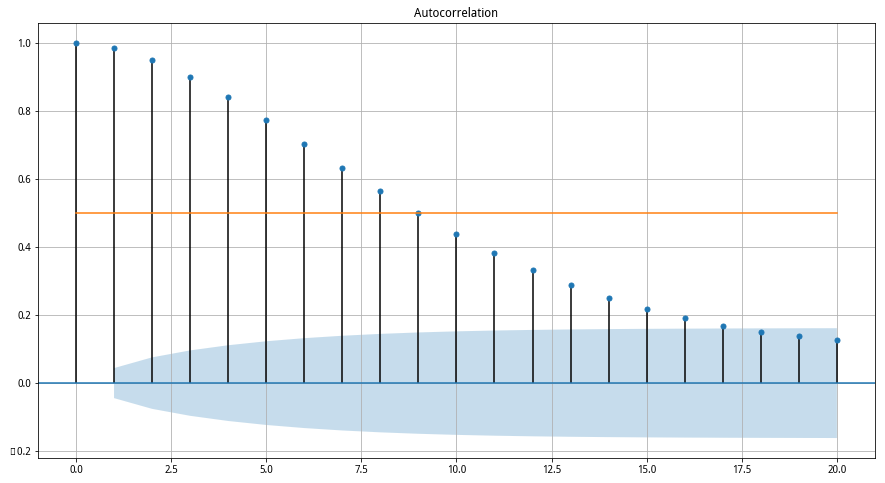

In [388]:
## 画出每日筛选出最强动量后的因子自相关函数
fig, ax = plt.subplots(figsize=(15,8))
plot_acf(pd.DataFrame(test).iloc[:,0].dropna(),lags=20,ax=ax,label='a')
plt.plot([0.5]*21)
plt.grid()

# 动量因子测试结论：


a) 对这几只ETF，动量因子的IC值显著大于0；

b) 选择合适参数的动量因子，其对未来合适周期的走势具有较好的预测作用；

c) 在不考虑择时的条件下，仅用动量因子在这些ETF之间轮动，IC也是显著有效的，持仓周期约10天，这与不择时条件下的回测结果是吻合的（收益大概~200%,从2018.1.1-2021.10.29）。考虑择时的结果还需要进一步分析。

d) 若扩大ETF池，则因子IC的分布将会有更多的分布在0附近，意味着因子有更大的概率失败，相当于增大了噪声。对于波动性与持续性更强的品种，因子IC的分布更趋向于向±1集中，且因子IC的半衰期更长，这与回测结果是吻合的。因此要尽量限制ETF池的数量不要太多，且ETF品种之间的关联性越低越好、ETF品种自身的波动性越大越好、与趋势延续性越久越好。

e) RSRS择时因子的效果还未考虑，后面学会了再搞。